In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing
from sklearn import *
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import (
    RobustScaler,
    StandardScaler)
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import (
    Ridge,
    RidgeCV,
    Lasso,
    LassoCV
)
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score)
from sklearn.svm import LinearSVR
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv


# California Housing Price Prediction

## Exploring preprocessing, feature engineering, and linear regression pipelines on tabular housing data.

This project focuses on building a structured regression workflow for predicting California housing prices using classical machine learning techniques.

The primary goal was not only to train models, but also to understand:

- how data distributions affect model behavior,
- how preprocessing choices influence optimization,
- how engineered features improve signal quality,
- and where linear models begin to struggle on nonlinear datasets.

---

# Problem Statement

The objective of this project is to predict median house prices in California districts using demographic and housing-related features.

Rather than immediately testing complex models, the project emphasizes:

- exploratory data analysis,
- preprocessing strategy design,
- feature engineering,
- proper train/validation/test discipline,
- and comparison between different linear optimization approaches.

This project aims to build practical intuition about regression pipelines and structured ML experimentation.

# Importing Libraries

The project uses:

- NumPy and Pandas for data handling
- Matplotlib  for visualization
- Scikit-learn for preprocessing, modeling, and evaluation

In [2]:
dataset=pd.read_csv("/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv")

# Understanding the Dataset

The California Housing dataset contains district-level housing information collected from the 1990 California census.

Features include:

- geographical coordinates,
- housing statistics,
- population-related information,
- income statistics,
- and proximity to the ocean.

The target variable is:

`median_house_value`

which represents the median house price for a district.

# Initial Data Exploration

Before building models, the dataset is explored to understand:

- feature distributions,
- missing values,
- outliers,
- feature relationships,
- and potential preprocessing requirements.

This step is critical because model quality heavily depends on data quality and representation.

In [3]:
dataset.info

<bound method DataFrame.info of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  

In [4]:
dataset.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Missing Value Analysis

The dataset contains missing values in:

`total_bedrooms`

Since the distribution is skewed and contains outliers, median imputation is preferred over mean imputation because it is more robust to extreme values.

In [6]:
dataset.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

# Distribution Analysis

Understanding feature distributions is important because machine learning models are heavily influenced by:

- feature scale,
- skewness,
- outliers,
- and variance structure.

Before applying preprocessing, histograms and boxplots are analyzed to study how different numerical features behave.

This helps determine:
- whether transformations are required,
- which scaling strategy is appropriate,
- and whether extreme values may distort optimization.

In [7]:
target = "median_house_value"


In [8]:
num_cols = dataset.select_dtypes(include=np.number).columns


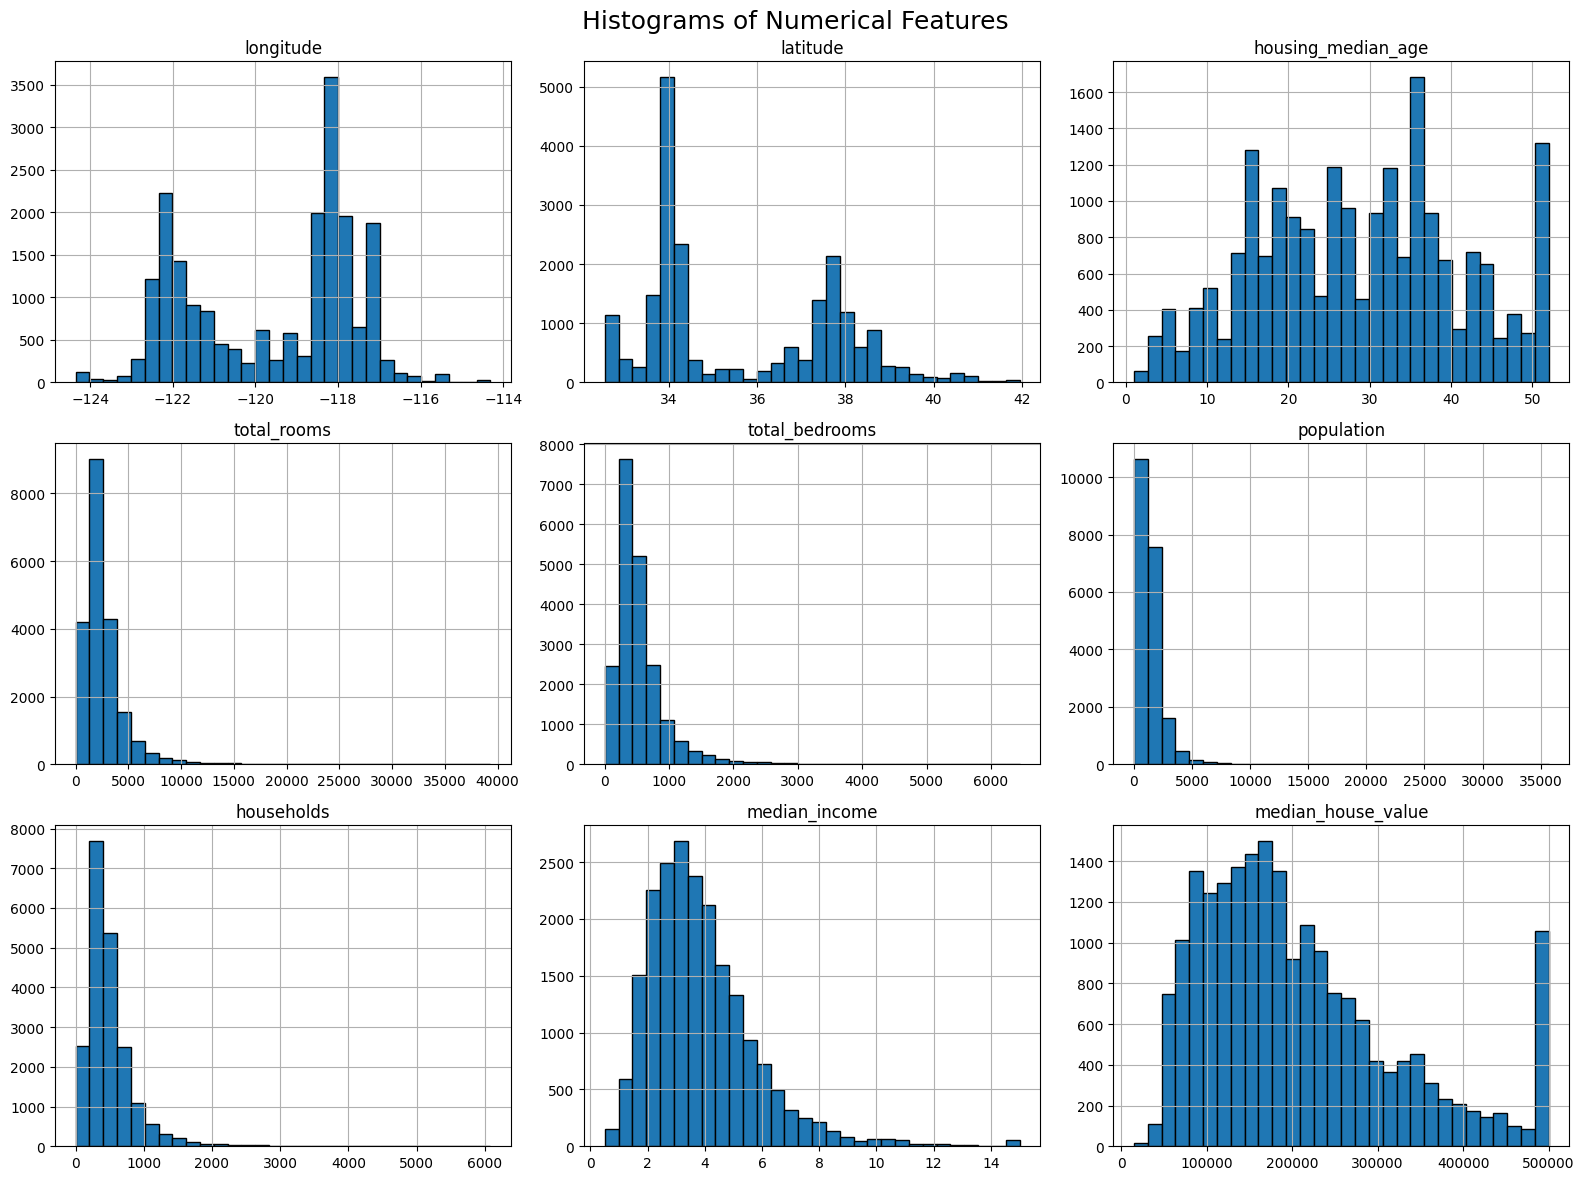

In [9]:
#histograms
dataset[num_cols].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Histograms of Numerical Features", fontsize=18)

plt.tight_layout()
plt.show()

## Distribution of `total_rooms`

The histogram shows a strong right-skewed distribution.

Most districts contain relatively fewer rooms, while a smaller number of districts contain extremely large room counts.

The long right tail indicates the presence of high-value outliers.

### Why this matters

Large skewness can:
- distort mean-based statistics,
- negatively affect scaling,
- and disproportionately influence linear models.

Since linear regression is sensitive to feature magnitude, extremely large values may dominate optimization and coefficient estimation.

### Observation

Raw room counts may not be the most informative representation because districts naturally vary in population and household size.

This motivated later feature engineering using:
- `rooms_per_household`
instead of relying only on raw totals.

## Distribution of `total_bedrooms`

The feature shows a similar right-skewed pattern with several large outliers.

Additionally, missing values are present in this column.

### Why this matters

The skewed distribution suggests that:
- mean imputation may become unstable,
- and extreme districts may heavily influence averages.

For this reason, median imputation is preferred because it is more robust to outliers.

### Observation

The feature also appears highly correlated with `total_rooms`, suggesting possible redundancy between the two raw count features.

## Distribution of `population`

The population feature exhibits one of the strongest right-skewed distributions in the dataset.

Most districts have moderate population sizes, while a small number contain extremely dense populations.

### Why this matters

Highly skewed population features can:
- increase variance,
- create unstable scaling behavior,
- and reduce the effectiveness of gradient-based optimization.

Extreme population values may also dominate model learning even if they are not proportionally informative.

### Observation

Raw population alone may not capture meaningful housing behavior.

This motivated the creation of:
- `population_per_household`

which provides a normalized representation of district density.

## Distribution of `households`

The households feature also follows a right-skewed distribution with visible outliers.

The overall shape is similar to:
- total_rooms
- total_bedrooms
- population

which suggests that many raw count-based features are structurally related.

### Why this matters

Strong correlations among raw totals can introduce redundancy into linear models.

Instead of using only raw counts, ratio-based features may better represent living conditions and housing density.

## Distribution of `median_income`

The distribution of median income is right-skewed but noticeably more structured compared to raw count-based features.

Most districts cluster around lower-to-mid income ranges, while fewer districts extend into very high income levels.

### Why this matters

Income is expected to strongly influence housing prices, making this feature particularly important.

However, the presence of skewness and outliers means scaling decisions become critical.

### Observation

Correlation analysis later confirms that:
`median_income`
has the strongest relationship with house prices among numerical features.

Because of outliers, RobustScaler is preferred over StandardScaler for this feature.

## Distribution of `housing_median_age`

The housing age distribution is comparatively more stable and less skewed than many other numerical features.

The values are spread across a moderate range without extremely large outliers.

### Why this matters

Features with relatively stable distributions are generally easier for linear models to handle.

Since the feature does not contain severe skewness or extreme tails, standard normalization methods are sufficient.

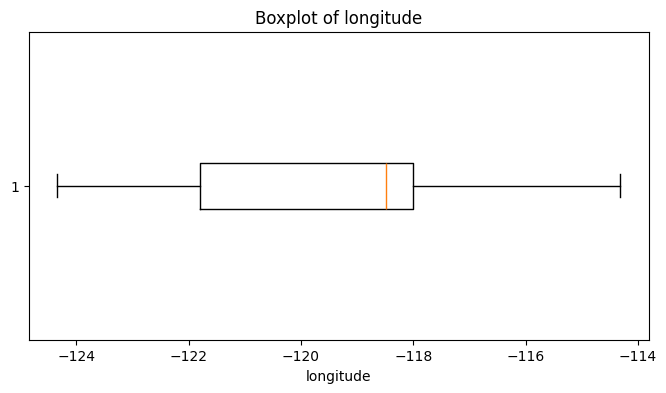

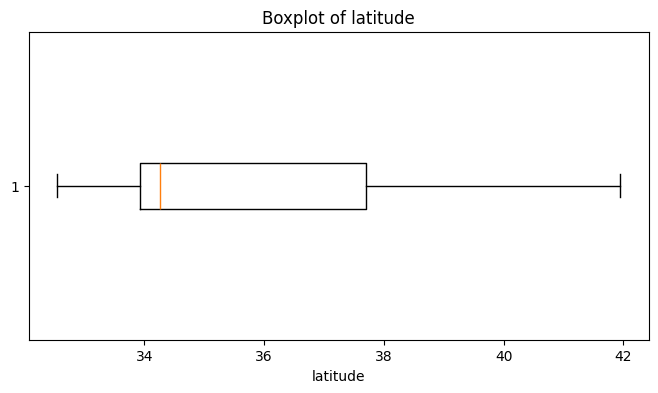

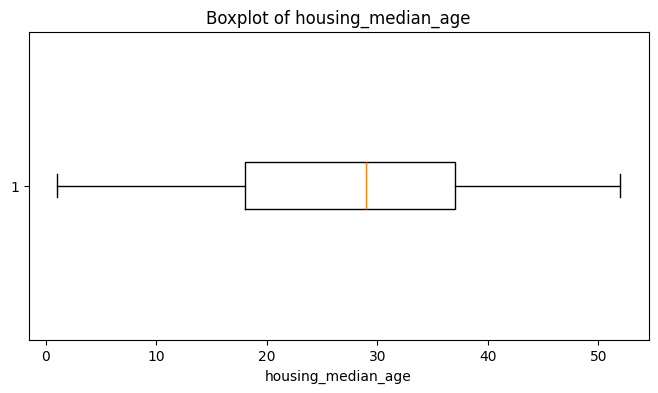

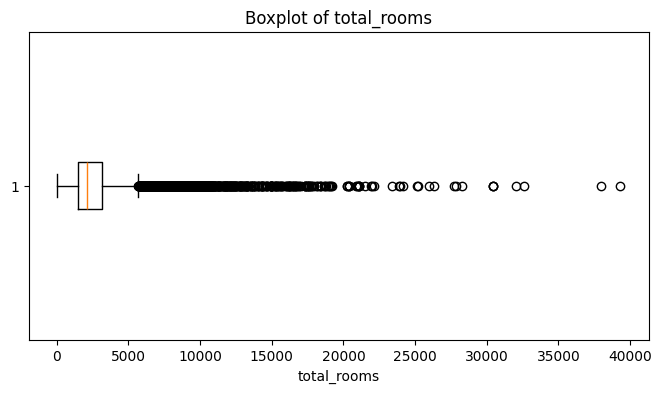

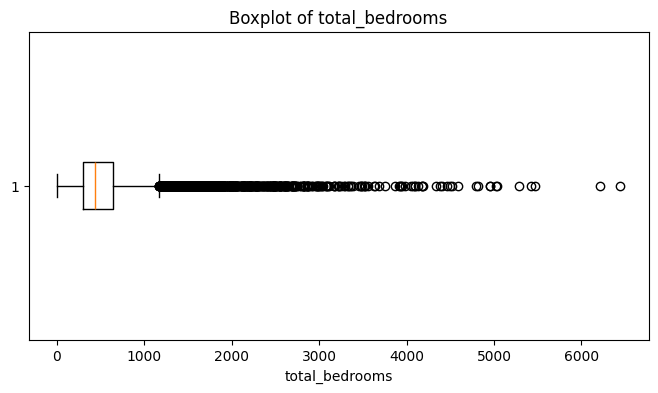

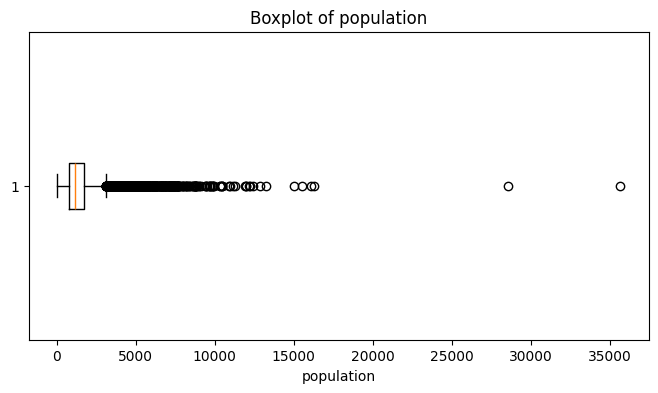

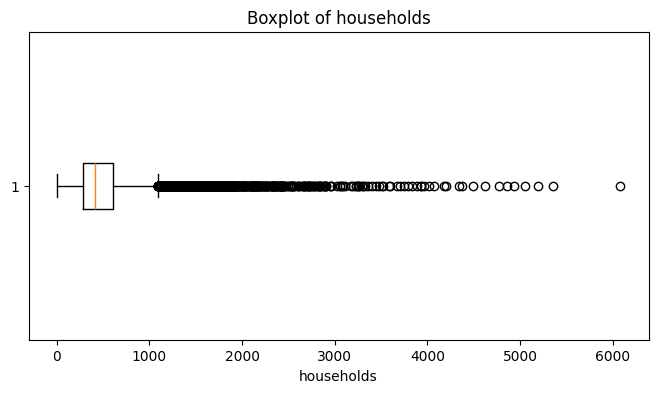

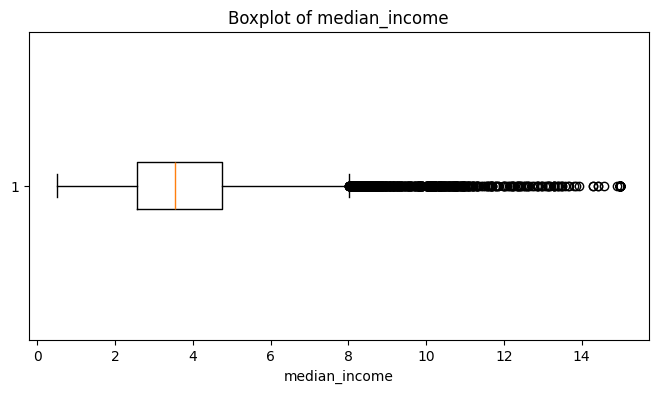

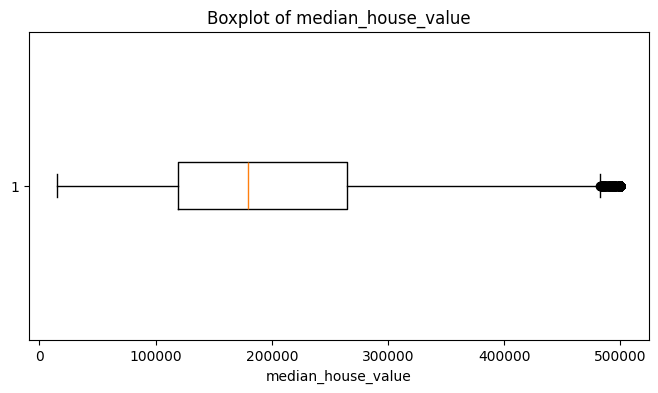

In [10]:
# box plots
for col in num_cols:
    
    plt.figure(figsize=(8, 4))
    
    plt.boxplot(dataset[col].dropna(), vert=False)
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.show()

# Boxplot Analysis

Boxplots provide a clearer view of:
- outliers,
- spread,
- and median positioning.

Several features show extreme outliers extending far beyond the interquartile range.
I have preffered not to remove the outliers since they can be the high income households or buisnesses, hence removing them would make the model less known or sensitive about such data

### Key observations

- Numerical count-based features contain significant high-end outliers.
- Median values are compressed near the lower range due to skewness.
- Variance differs substantially across features.

### Why this matters

Outliers can strongly affect:
- mean-based scaling,
- coefficient estimation,
- and gradient optimization.

These observations influenced the decision to:
- use RobustScaler for selected features,
- apply log transformations,
- and engineer normalized ratio-based features.

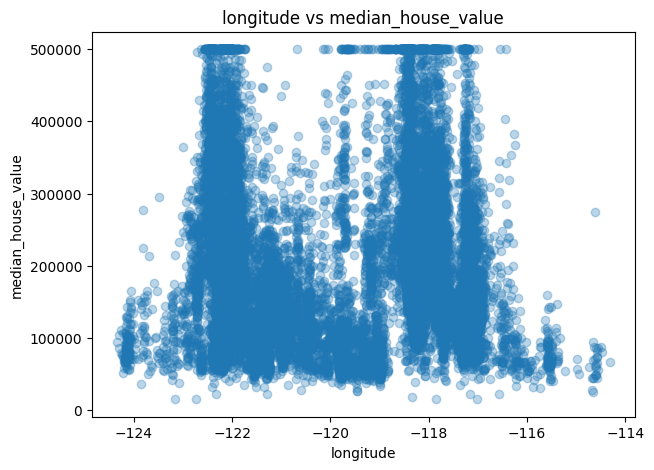

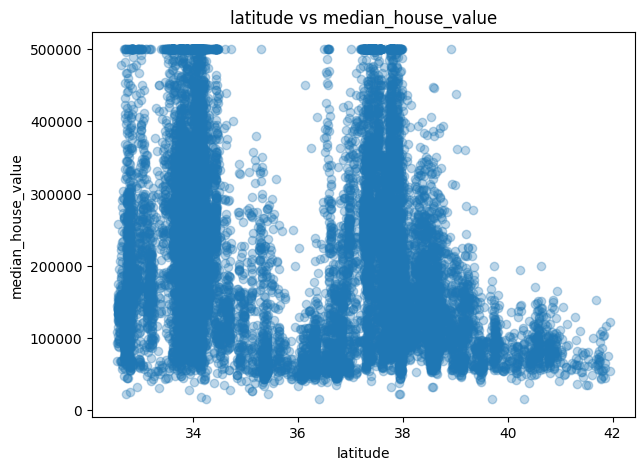

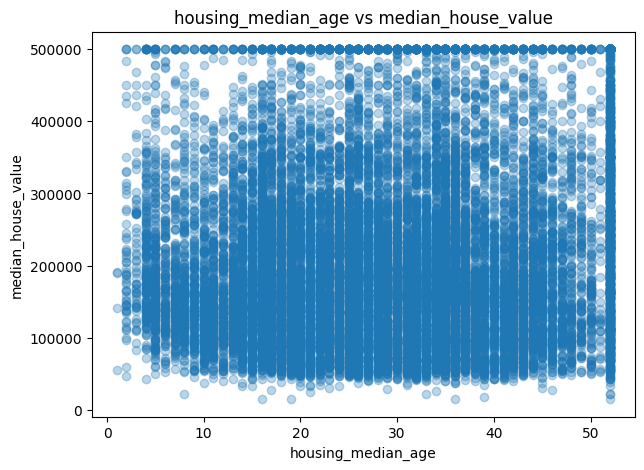

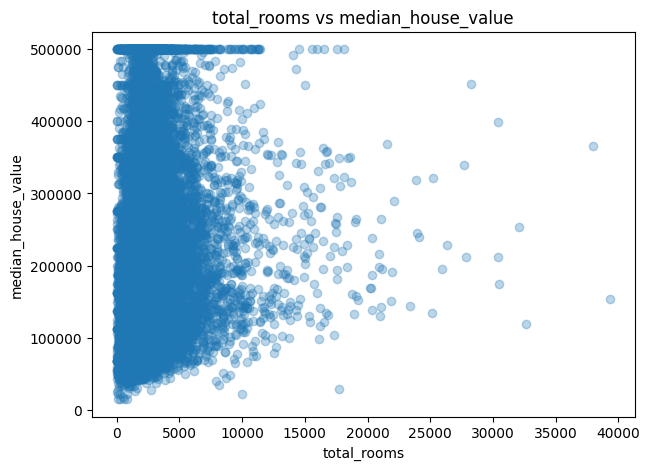

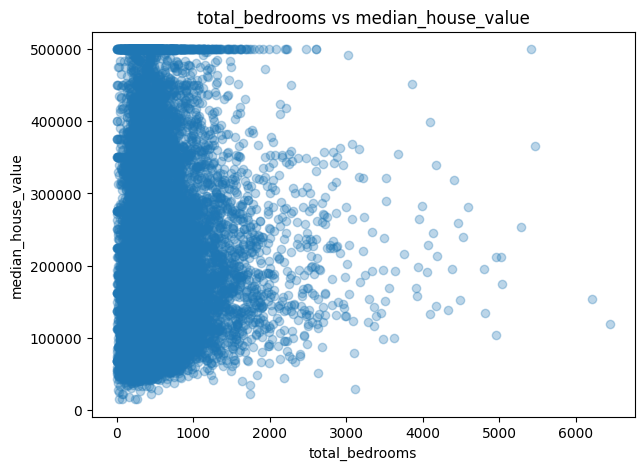

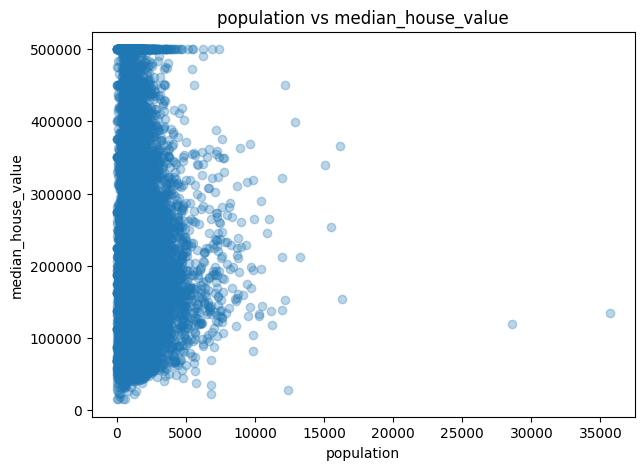

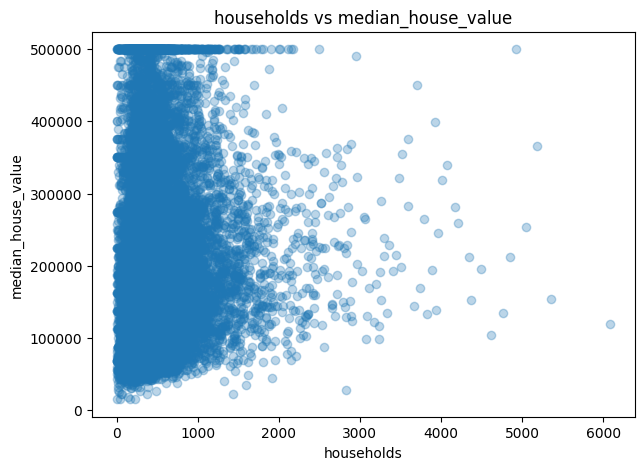

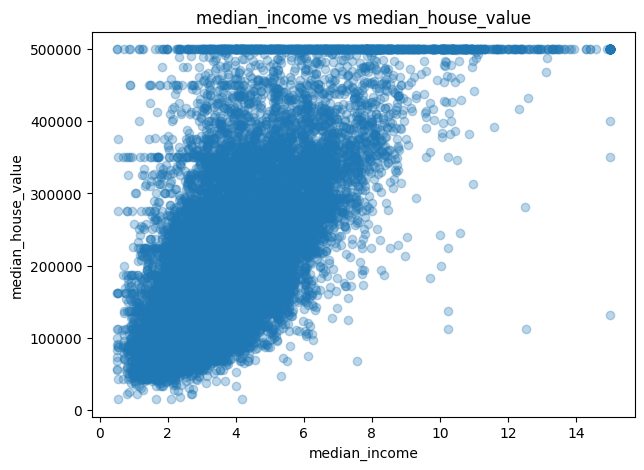

In [11]:
# scatter plots
for col in num_cols:
    
    if col != target:
        
        plt.figure(figsize=(7, 5))
        
        plt.scatter(
            dataset[col],
            dataset[target],
            alpha=0.3
        )
        
        plt.xlabel(col)
        plt.ylabel(target)
        
        plt.title(f"{col} vs {target}")
        
        plt.show()

# Correlation Heatmap Analysis

The heatmap helps visualize linear relationships between features and the target variable.

### Key observations

- `median_income` shows the strongest positive correlation with house prices.
- `bedrooms_per_room` later exhibits a negative relationship with house prices.
- Many raw count-based features are strongly correlated with one another.

### Geographic Insight

The relationship between:
- latitude,
- longitude,
- and house prices

appears nonlinear and spatially clustered rather than purely linear.

This suggests that linear regression may struggle to fully capture geographic housing behavior.

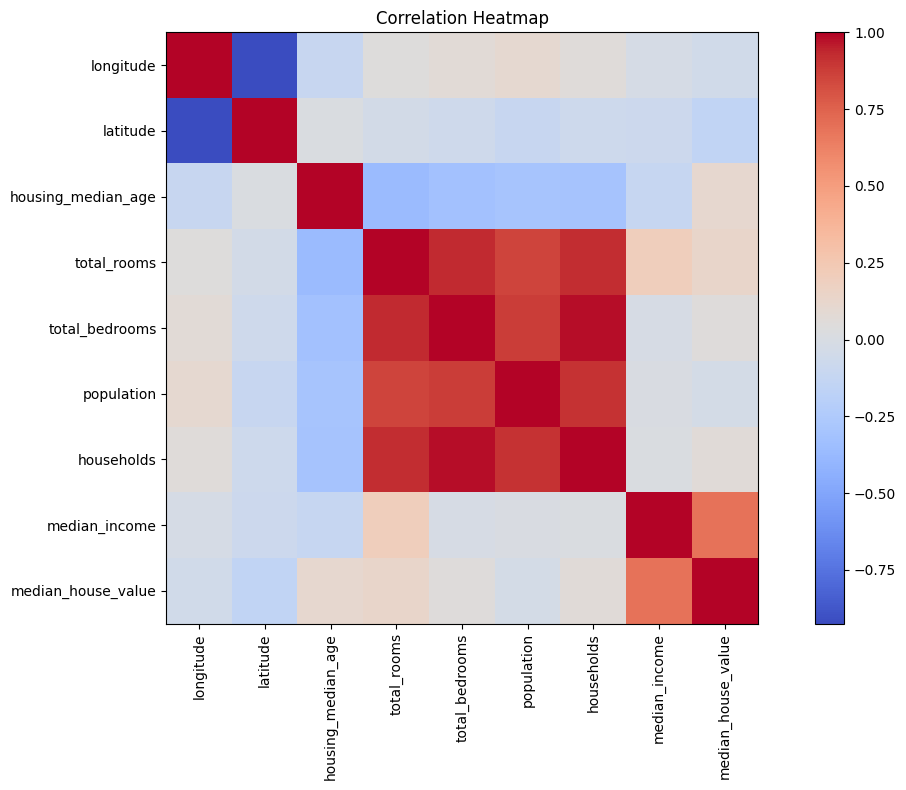

In [12]:
#correlation heatmaps
corr_matrix = dataset[num_cols].corr()

plt.figure(figsize=(12, 8))

img = plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

# Axis labels
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

# Colorbar
plt.colorbar(img)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


# Train / Validation / Test Split

The dataset is divided into:

- Training Set → model learning
- Validation Set → experimentation and tuning
- Test Set → final unbiased evaluation

Data preprocessing steps are fitted only on the training set to avoid data leakage.

In [13]:
X = dataset.drop("median_house_value", axis=1)

y = dataset["median_house_value"]

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [15]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [16]:
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (14448, 9)
Validation shape: (3096, 9)
Test shape: (3096, 9)


In [17]:
num_cols = X_train.select_dtypes(include=np.number).columns

cat_cols = X_train.select_dtypes(exclude=np.number).columns

print("\nNumerical columns:\n", num_cols)

print("\nCategorical columns:\n", cat_cols)


Numerical columns:
 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

Categorical columns:
 Index(['ocean_proximity'], dtype='object')


In [18]:
imputer = SimpleImputer(strategy="median")

imputer.fit(X_train[["total_bedrooms"]])

X_train["total_bedrooms"] = imputer.transform(
    X_train[["total_bedrooms"]]
)

X_val["total_bedrooms"] = imputer.transform(
    X_val[["total_bedrooms"]]
)

X_test["total_bedrooms"] = imputer.transform(
    X_test[["total_bedrooms"]]
)

# Feature Engineering

Raw count-based features often contain less useful information than ratio-based representations.

To capture more meaningful relationships, the following engineered features are created:

- rooms_per_household
- bedrooms_per_room
- population_per_household

These features help normalize district-level differences and reduce redundancy among highly correlated raw totals.

In [19]:
def add_features(data):

    data = data.copy()

    data["rooms_per_household"] = (
        data["total_rooms"] / data["households"]
    )

    data["bedrooms_per_room"] = (
        data["total_bedrooms"] / data["total_rooms"]
    )

    data["population_per_household"] = (
        data["population"] / data["households"]
    )

    return data

In [20]:
X_train = add_features(X_train)

X_val = add_features(X_val)

X_test = add_features(X_test)

In [21]:
drop_cols = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households"
]

X_train = X_train.drop(columns=drop_cols)

X_val = X_val.drop(columns=drop_cols)

X_test = X_test.drop(columns=drop_cols)

In [22]:
print("\nTrain columns:\n")

print(X_train.columns)

print("\nAny NaNs left?\n")

print(X_train.isnull().sum())

print("\nSample data:\n")

print(X_train.head())


Train columns:

Index(['longitude', 'latitude', 'housing_median_age', 'median_income',
       'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household'],
      dtype='object')

Any NaNs left?

longitude                   0
latitude                    0
housing_median_age          0
median_income               0
ocean_proximity             0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64

Sample data:

       longitude  latitude  housing_median_age  median_income ocean_proximity  \
7061     -118.02     33.93                35.0         4.1312       <1H OCEAN   
14689    -117.09     32.79                20.0         2.8631      NEAR OCEAN   
17323    -120.14     34.59                24.0         4.2026      NEAR OCEAN   
10056    -121.00     39.26                14.0         3.1094          INLAND   
15750    -122.45     37.77                52.0         3.3068        NEAR BAY   

       rooms

# Encoding Categorical Features

The feature:

`ocean_proximity`

is categorical and cannot be used directly by linear regression models.

One-Hot Encoding is applied to convert categories into numerical representations.

`drop='first'` is used to avoid multicollinearity caused by the dummy variable trap.

In [23]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoder.fit(X_train[["ocean_proximity"]])

X_train_encoded = encoder.transform(
    X_train[["ocean_proximity"]]
)

X_val_encoded = encoder.transform(
    X_val[["ocean_proximity"]]
)

X_test_encoded = encoder.transform(
    X_test[["ocean_proximity"]]
)


encoded_cols = encoder.get_feature_names_out(
    ["ocean_proximity"]
)



X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_cols,
    index=X_val.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

X_train = X_train.drop(columns=["ocean_proximity"])

X_val = X_val.drop(columns=["ocean_proximity"])

X_test = X_test.drop(columns=["ocean_proximity"])


X_train = pd.concat(
    [X_train, X_train_encoded],
    axis=1
)

X_val = pd.concat(
    [X_val, X_val_encoded],
    axis=1
)

X_test = pd.concat(
    [X_test, X_test_encoded],
    axis=1
)

print("\nFinal columns:\n")

print(X_train.columns)

print("\nTrain shape:\n")

print(X_train.shape)

print("\nSample data:\n")

print(X_train.head())


Final columns:

Index(['longitude', 'latitude', 'housing_median_age', 'median_income',
       'rooms_per_household', 'bedrooms_per_room', 'population_per_household',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

Train shape:

(14448, 12)

Sample data:

       longitude  latitude  housing_median_age  median_income  \
7061     -118.02     33.93                35.0         4.1312   
14689    -117.09     32.79                20.0         2.8631   
17323    -120.14     34.59                24.0         4.2026   
10056    -121.00     39.26                14.0         3.1094   
15750    -122.45     37.77                52.0         3.3068   

       rooms_per_household  bedrooms_per_room  population_per_household  \
7061              5.882353           0.165833                  2.985294   
14689             4.401210           0.244617                  2.01

In [24]:
X_train = X_train.drop(
    columns=["ocean_proximity_<1H OCEAN"]
)

X_val = X_val.drop(
    columns=["ocean_proximity_<1H OCEAN"]
)

X_test = X_test.drop(
    columns=["ocean_proximity_<1H OCEAN"]
)

# Re evaluating and visualizing all the distributions and correlations

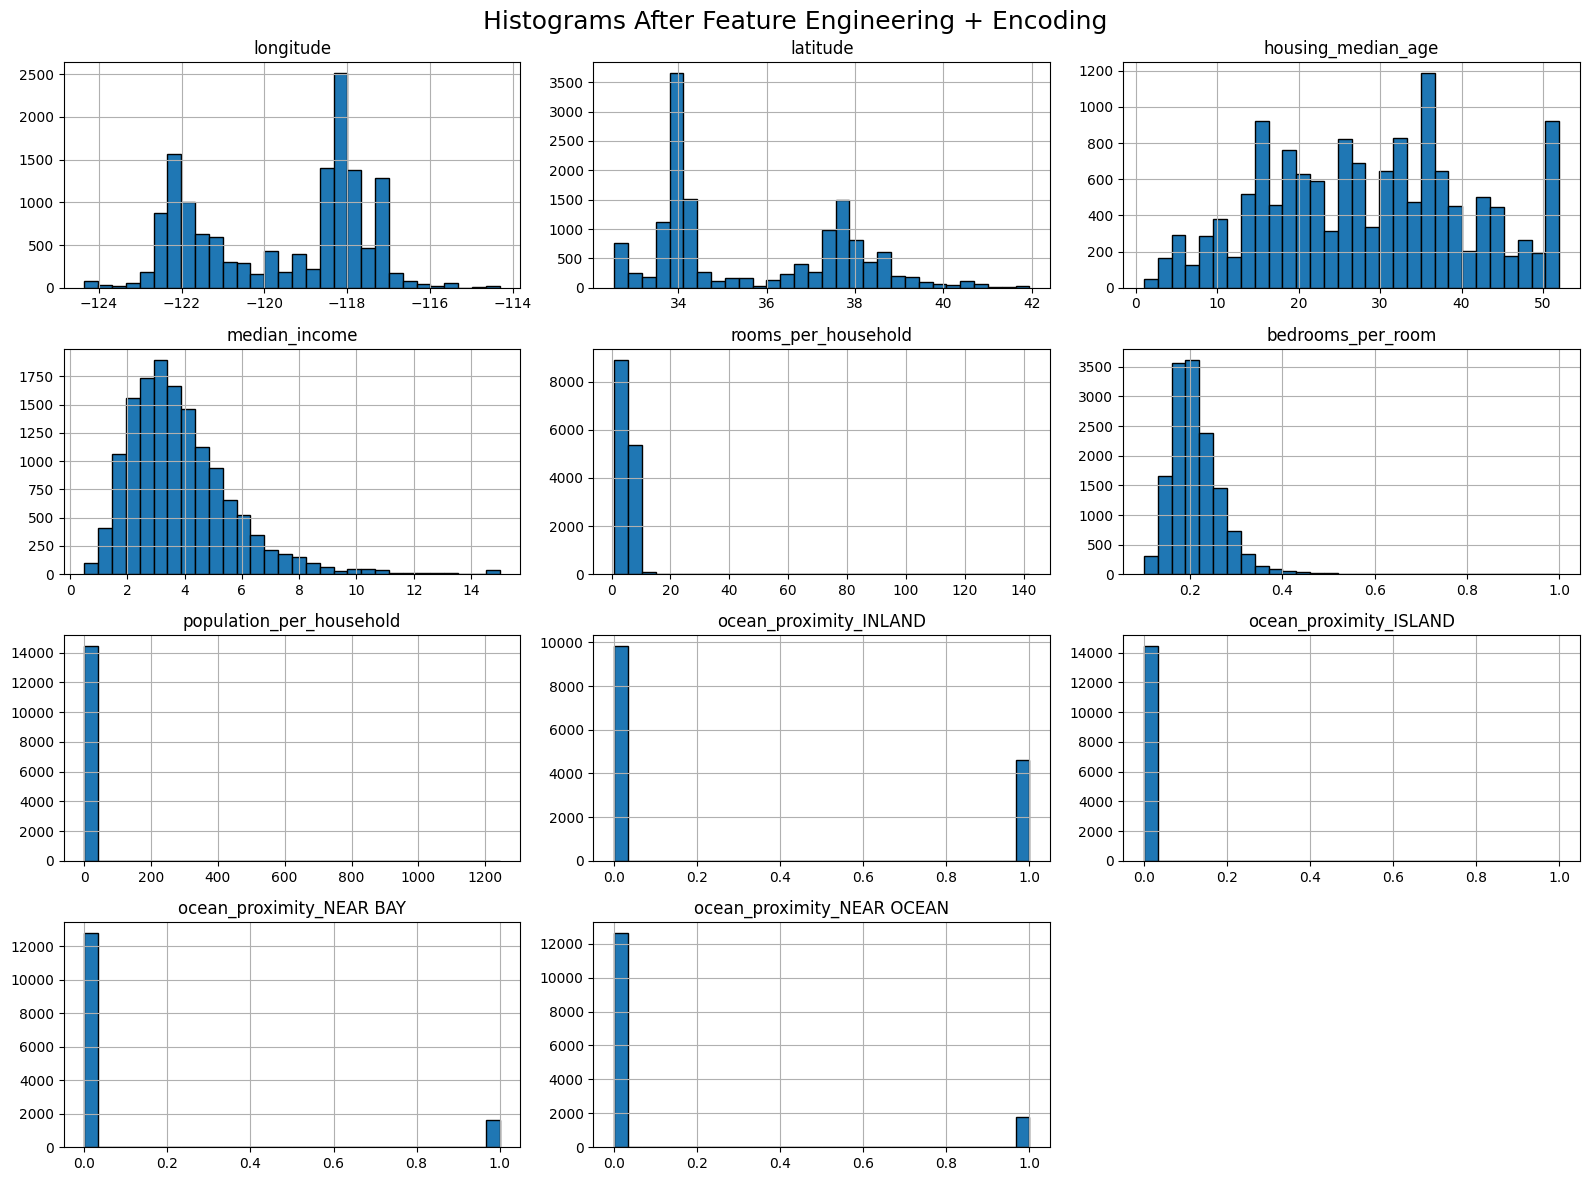

In [25]:
X_train.hist(
    figsize=(16, 12),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Histograms After Feature Engineering + Encoding",
    fontsize=18
)

plt.tight_layout()

plt.show()


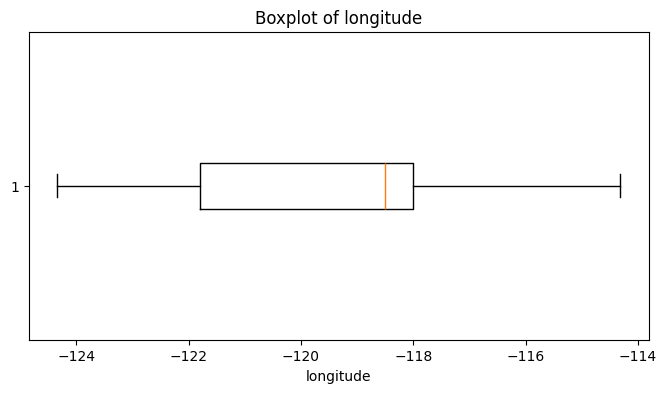

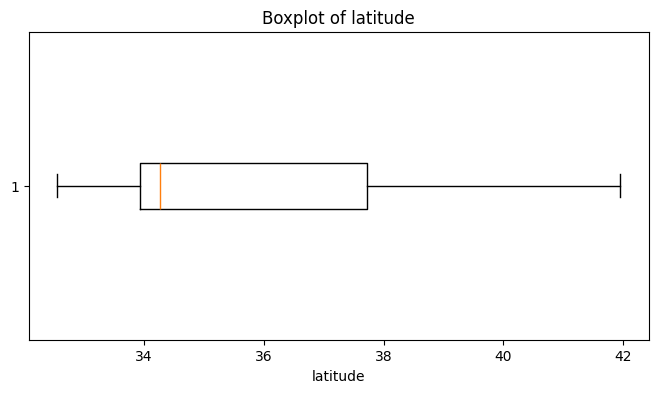

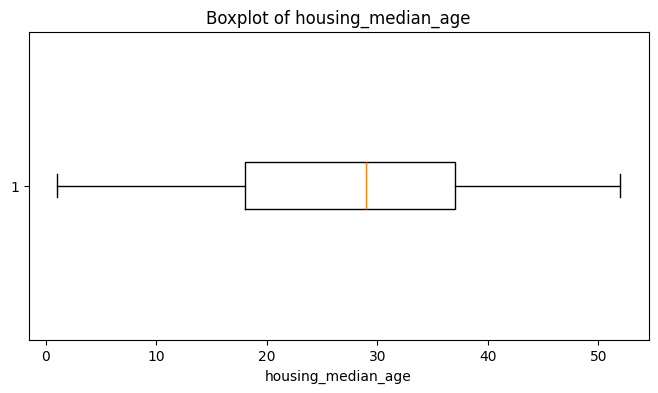

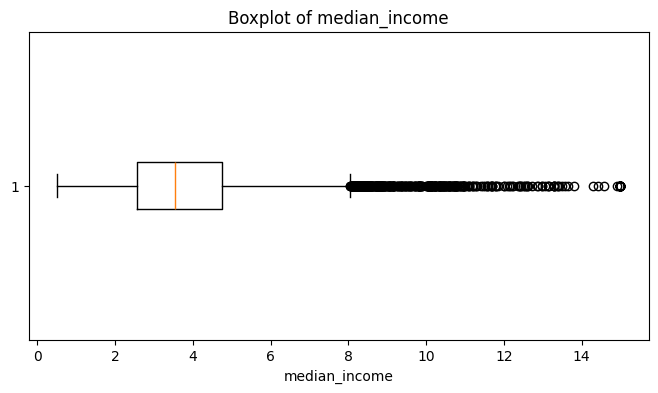

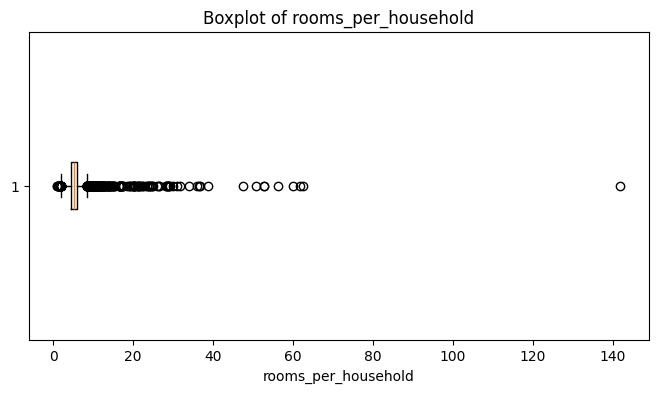

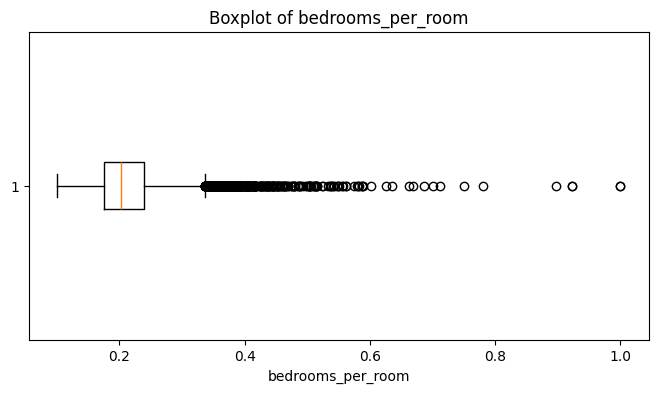

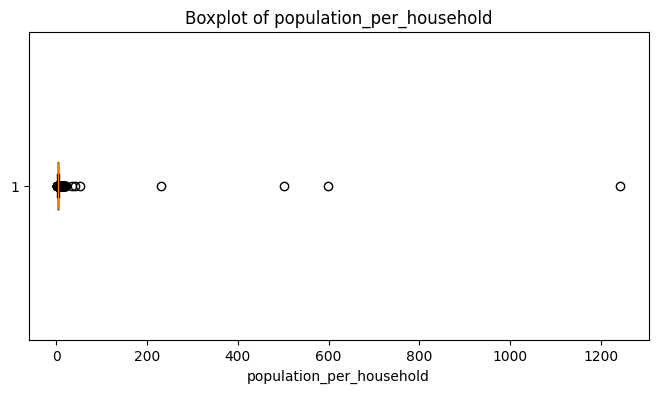

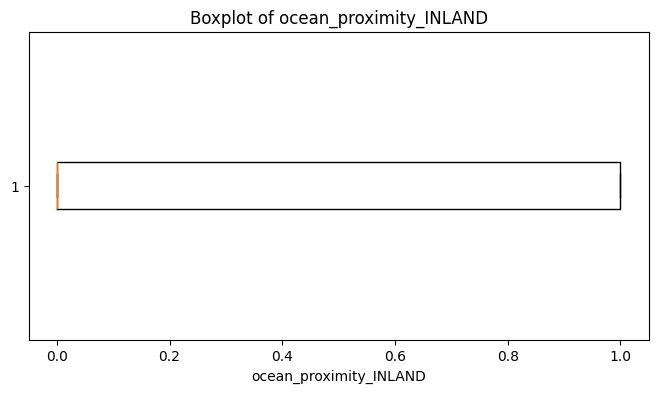

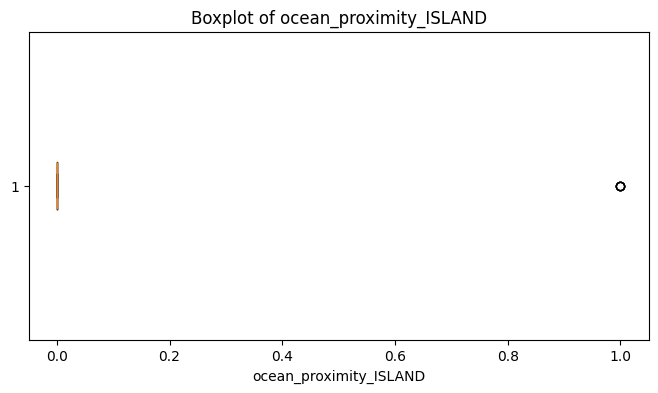

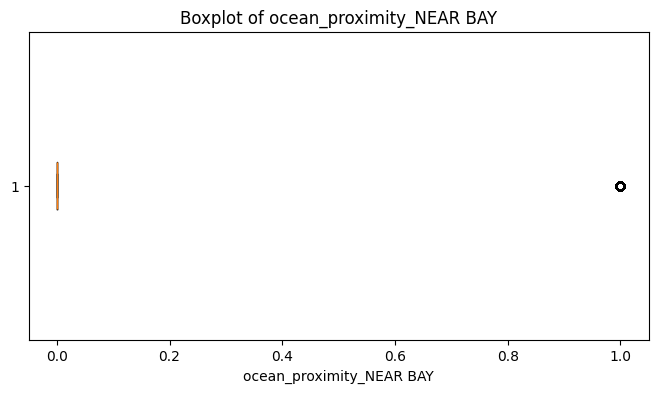

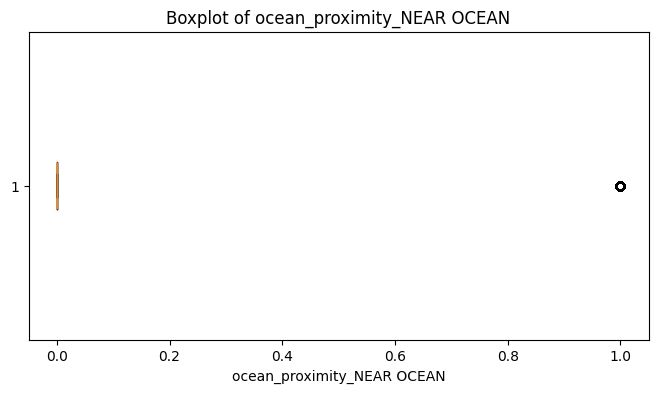

In [26]:
for col in X_train.columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        X_train[col].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {col}")

    plt.xlabel(col)

    plt.show()


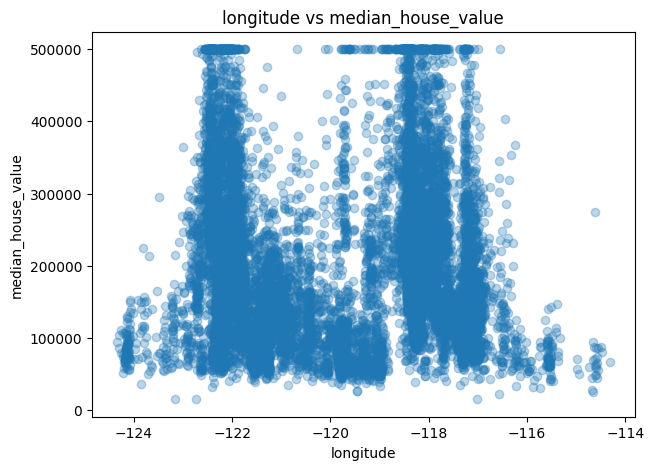

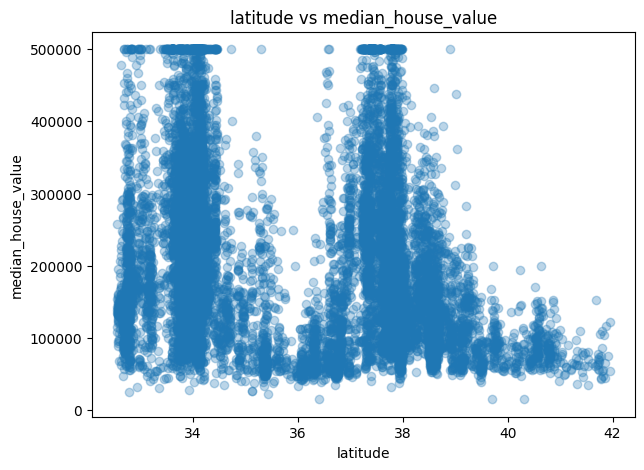

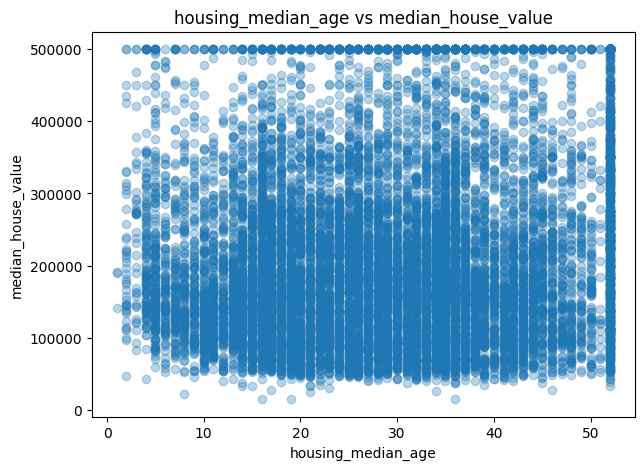

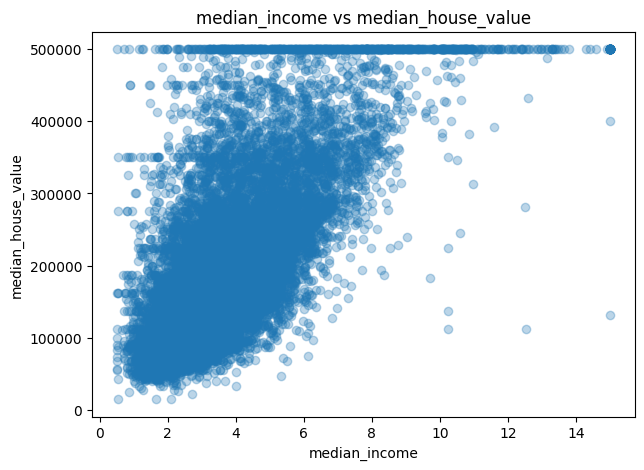

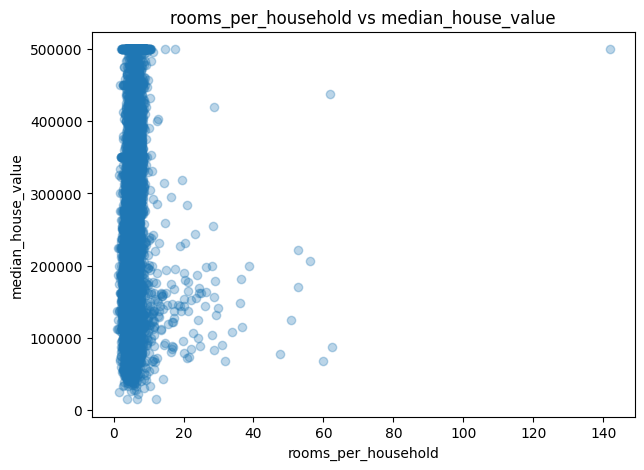

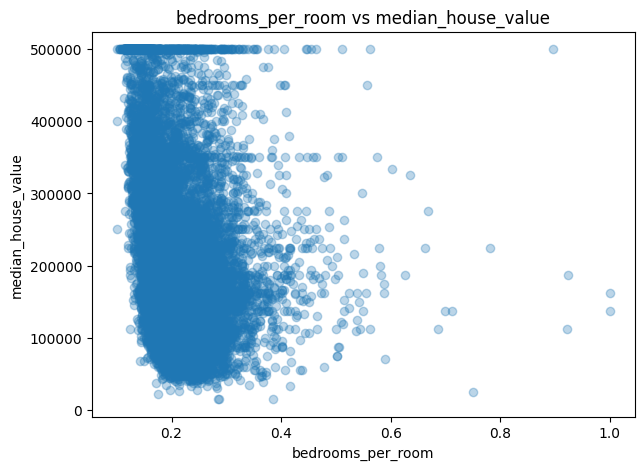

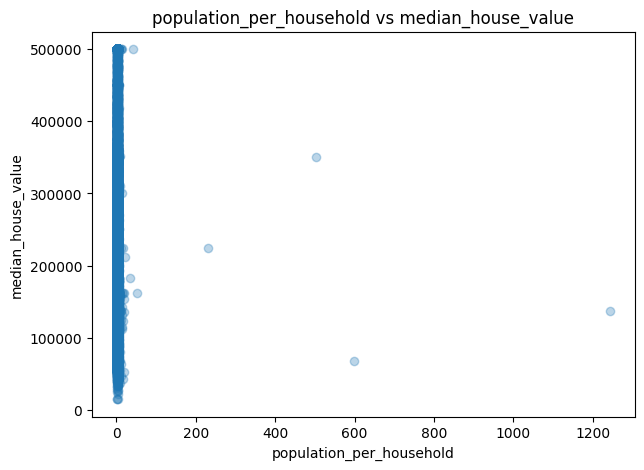

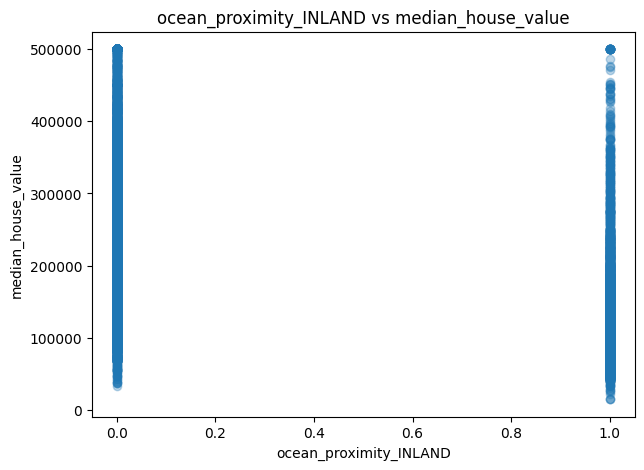

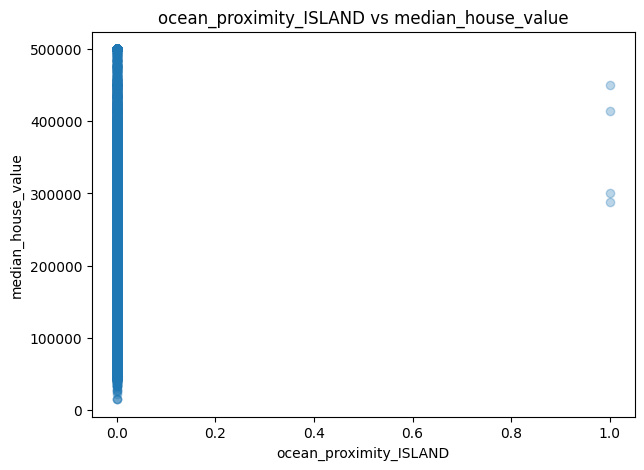

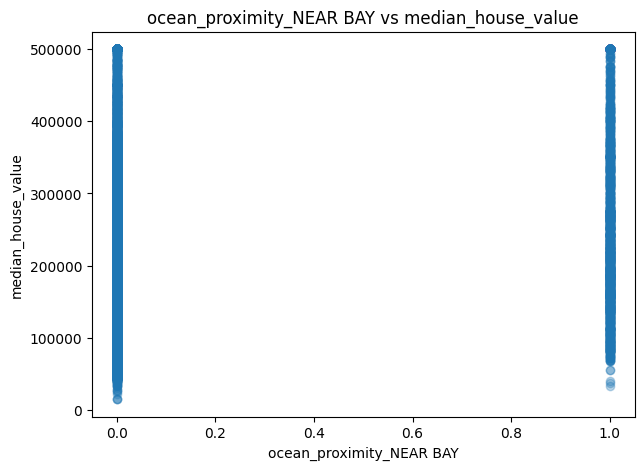

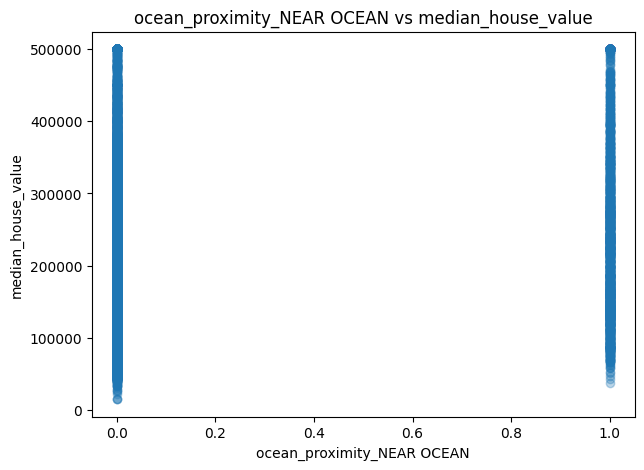

In [27]:
for col in X_train.columns:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        X_train[col],
        y_train,
        alpha=0.3
    )

    plt.xlabel(col)

    plt.ylabel("median_house_value")

    plt.title(f"{col} vs median_house_value")

    plt.show()

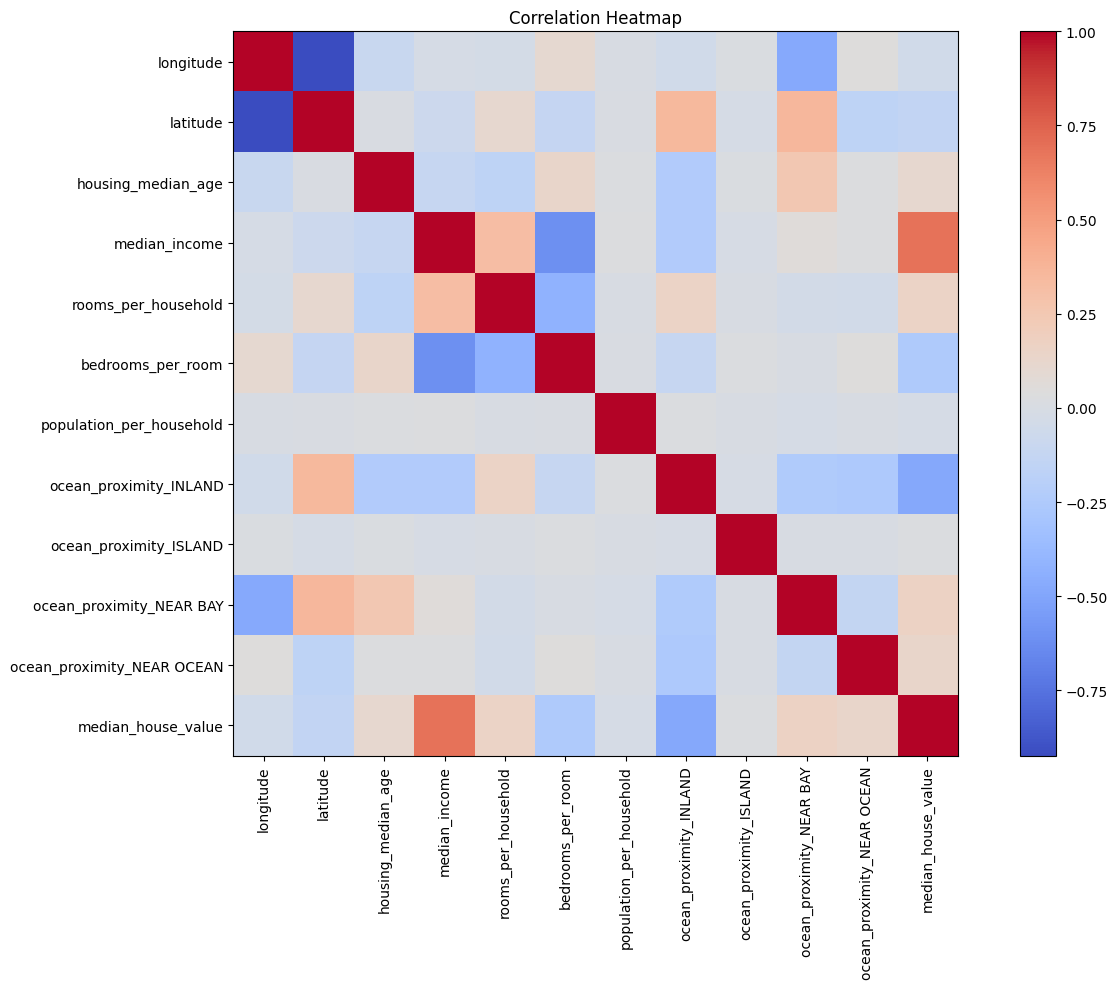

In [28]:
train_corr_df = X_train.copy()

train_corr_df["median_house_value"] = y_train

corr_matrix = train_corr_df.corr()

plt.figure(figsize=(14, 10))

img = plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.colorbar(img)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# Preprocessing Strategy

Different features require different preprocessing strategies depending on their distributions.

Applying the same scaling method to all features can distort information and negatively affect optimization.

The preprocessing pipeline is designed based on distribution behavior observed during EDA.

---

## Log Transformations

Applied to heavily skewed ratio-based features to reduce extreme tails and stabilize variance.

---

## Robust Scaling

Used for features containing significant outliers.

Unlike StandardScaler, RobustScaler relies on median and IQR, making it less sensitive to extreme values.

---

## Standard Scaling

Used for relatively stable features with more symmetric distributions.

This helps gradient-based optimization converge more efficiently.

In [29]:
X_train_processed = X_train.copy()

X_val_processed = X_val.copy()

X_test_processed = X_test.copy()


In [30]:
log_cols = [
    "rooms_per_household",
    "population_per_household"
]

for col in log_cols:

    X_train_processed[col] = np.log1p(
        X_train_processed[col]
    )

    X_val_processed[col] = np.log1p(
        X_val_processed[col]
    )

    X_test_processed[col] = np.log1p(
        X_test_processed[col]
    )

In [31]:
robust_cols = [
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household"
]

robust_scaler = RobustScaler()

robust_scaler.fit(
    X_train_processed[robust_cols]
)

X_train_processed[robust_cols] = (
    robust_scaler.transform(
        X_train_processed[robust_cols]
    )
)

X_val_processed[robust_cols] = (
    robust_scaler.transform(
        X_val_processed[robust_cols]
    )
)

X_test_processed[robust_cols] = (
    robust_scaler.transform(
        X_test_processed[robust_cols]
    )
)

In [32]:
standard_cols = [
    "longitude",
    "latitude",
    "housing_median_age"
]

standard_scaler = StandardScaler()

# Fit ONLY on train
standard_scaler.fit(
    X_train_processed[standard_cols]
)

# Transform train / val / test
X_train_processed[standard_cols] = (
    standard_scaler.transform(
        X_train_processed[standard_cols]
    )
)

X_val_processed[standard_cols] = (
    standard_scaler.transform(
        X_val_processed[standard_cols]
    )
)

X_test_processed[standard_cols] = (
    standard_scaler.transform(
        X_test_processed[standard_cols]
    )
)

In [33]:
print("\nProcessed Train Data:\n")

print(X_train_processed.head())

print("\nShape:\n")

print(X_train_processed.shape)


Processed Train Data:

       longitude  latitude  housing_median_age  median_income  \
7061    0.780934 -0.805682            0.509357       0.270260   
14689   1.245270 -1.339473           -0.679873      -0.308556   
17323  -0.277552 -0.496645           -0.362745       0.302850   
10056  -0.706938  1.690024           -1.155565      -0.196134   
15750  -1.430902  0.992350            1.857152      -0.106032   

       rooms_per_household  bedrooms_per_room  population_per_household  \
7061              0.382811          -0.577424                  0.194988   
14689            -0.552408           0.647066                 -1.068382   
17323             0.231392          -0.417236                 -0.309227   
10056             0.375634          -0.257463                 -0.814105   
15750            -0.276699           0.296824                 -0.660976   

       ocean_proximity_INLAND  ocean_proximity_ISLAND  \
7061                      0.0                     0.0   
14689               

In [34]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# Linear SVR Regression

## Overview
After experimenting with Linear Regression, Ridge, Lasso, Polynomial Regression, and SGDRegressor, the next step was to explore Support Vector Regression (SVR).

The first SVR model implemented was `LinearSVR`, which applies the margin-based principles of Support Vector Machines to regression tasks while still maintaining a linear decision function.

Unlike Linear Regression which minimizes ordinary least squares directly, LinearSVR attempts to fit data within an epsilon-insensitive margin while maximizing stability.

---

# Why LinearSVR?

The dataset already showed:
- nonlinear relationships
- skewed distributions
- variance increasing with price
- capped target values around \$500,000

However, before jumping into nonlinear kernels, a linear-margin baseline was created using LinearSVR to compare:
- traditional linear regression
vs
- margin-based linear regression

---

# Preprocessing Used

The preprocessing pipeline included:

- Log transformation for skewed features
- Robust Scaling for outlier-heavy columns
- Standard Scaling for near-normal columns
- Log transformation of the target column (`median_house_value`)

Target transformation:

```python
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

In [35]:
linear_svr = LinearSVR(
    random_state=42,
    max_iter=50000,
    C=1.0
)
linear_svr.fit(
    X_train_processed,
    y_train_log
)

y_val_pred_log = linear_svr.predict(
    X_val_processed
)

# Convert back from log-space
y_val_pred = np.expm1(y_val_pred_log)

r2 = r2_score(y_val, y_val_pred)

mae = mean_absolute_error(
    y_val,
    y_val_pred
)

mse = mean_squared_error(
    y_val,
    y_val_pred
)

rmse = root_mean_squared_error(
    y_val,
    y_val_pred
)
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

R²   : 0.2237
MAE  : 52917.83
MSE  : 10113024439.43
RMSE : 100563.53


# Tuned RBF SVR Regression (GridSearchCV)

## Overview
After the weak performance of LinearSVR, a nonlinear Support Vector Regression model using the RBF (Radial Basis Function) kernel was implemented.

The RBF kernel allows the model to learn:
- nonlinear patterns
- local relationships
- similarity-based structures

instead of fitting a single global linear function.

This became the first major nonlinear kernel-based regression model in the project.

---

# Why RBF Kernel?

The housing dataset contained:
- nonlinear price behavior
- local geographic patterns
- clustered house values
- nonlinear income effects

A linear model could not capture these relationships effectively.

The RBF kernel works by measuring similarity between points in feature space, allowing the model to create nonlinear prediction boundaries automatically.

---

# Important Concept

Unlike Polynomial Regression, which manually creates nonlinear features:

```python
x², x³, x1*x2
```
RBF SVR instead learns nonlinear behavior through:

similarity geometry between data points.

This is known as the kernel trick.

In [36]:
param_grid = {
    'C': [1, 10, 100],
    'gamma': ['scale', 0.1, 0.01],
    'epsilon': [0.1, 0.2, 0.5]
}
rbf_svr = SVR(
    kernel='rbf'
)
grid_search = GridSearchCV(
    estimator=rbf_svr,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=2,
    n_jobs=-1
)
grid_search.fit(
    X_train_processed,
    y_train_log
)
best_svr = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

y_val_pred_log = best_svr.predict(
    X_val_processed
)

# Convert back from log-space
y_val_pred = np.expm1(y_val_pred_log)

r2 = r2_score(y_val, y_val_pred)

mae = mean_absolute_error(
    y_val,
    y_val_pred
)

mse = mean_squared_error(
    y_val,
    y_val_pred
)

rmse = root_mean_squared_error(
    y_val,
    y_val_pred
)
print("\n===== Tuned RBF SVR =====")

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters:
{'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}

===== Tuned RBF SVR =====
R²   : 0.7560
MAE  : 35680.76
MSE  : 3179192183.17
RMSE : 56384.33


# RandomizedSearchCV Tuned RBF SVR (Final Model)

## Overview
To further optimize the RBF SVR model while reducing computational overhead, `RandomizedSearchCV` was used.

Instead of exhaustively checking every combination like GridSearchCV, RandomizedSearchCV samples random combinations from the hyperparameter space.

This allows:
- broader parameter exploration
- reduced computational cost
- faster experimentation

while still achieving strong performance.

---

# Why RandomizedSearchCV?

GridSearchCV became computationally expensive because:
- RBF SVR is already heavy
- kernel methods compare data-point similarities
- cross-validation multiplies training cost

The RandomizedSearch approach provided a better balance between:
- search quality
- training time
- compute efficiency

---

# Parameter Space

```python
param_dist = {
    'C': [1, 5, 10, 50, 100, 300, 500],
    'gamma': ['scale', 0.1, 0.03, 0.01, 0.003, 0.001],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5]
}
```


In [37]:
param_dist = {
    'C': [1, 5, 10, 50, 100, 300, 500],
    'gamma': ['scale', 0.1, 0.03, 0.01, 0.003, 0.001],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5]
}
rbf_svr = SVR(
    kernel='rbf'
)
random_search = RandomizedSearchCV(
    estimator=rbf_svr,
    param_distributions=param_dist,
    n_iter=25,
    scoring='r2',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
random_search.fit(
    X_train_processed,
    y_train_log
)
best_svr_random = random_search.best_estimator_

print("\n===== BEST PARAMETERS =====")
print(random_search.best_params_)

y_val_pred_log = best_svr_random.predict(
    X_val_processed
)

# Convert back from log-space
y_val_pred = np.expm1(y_val_pred_log)

r2 = r2_score(y_val, y_val_pred)

mae = mean_absolute_error(
    y_val,
    y_val_pred
)

mse = mean_squared_error(
    y_val,
    y_val_pred
)

rmse = root_mean_squared_error(
    y_val,
    y_val_pred
)
print("\n===== RANDOM SEARCH RBF SVR =====")

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits

===== BEST PARAMETERS =====
{'gamma': 'scale', 'epsilon': 0.01, 'C': 5}

===== RANDOM SEARCH RBF SVR =====
R²   : 0.7654
MAE  : 35266.16
MSE  : 3056454937.87
RMSE : 55285.21


# Final Test Set Evaluation

## Overview
After completing:
- preprocessing
- feature engineering
- model comparisons
- hyperparameter tuning
- validation benchmarking

the best-performing model was finally evaluated on the completely untouched test set.

This step represents the true generalization performance of the model on unseen data.

The final model used was:

> RandomizedSearchCV Tuned RBF SVR

---

# Final Test Results

| Metric | Score |
|---|---|
| R² | 0.7853 |
| MAE | 34,261 |
| MSE | 2838397588.70 |
| RMSE | 53,276 |

---

# Interpretation of Results

## R² Score
```text
R² = 0.7853
```

The model successfully explained approximately:
> 78.5% of the variance in California housing prices.

This indicates strong nonlinear learning capability and good generalization performance on unseen data.

---

## Mean Absolute Error (MAE)
```text
MAE ≈ $34,261
```

On average, the model predictions deviated from actual house prices by around \$34k.

Considering:
- housing-market noise
- nonlinear geographic behavior
- clipped target values

this is a strong result for a classical machine learning regression model.

---

## RMSE
```text
RMSE ≈ $53,276
```

The RMSE being larger than MAE suggests:
- the model still makes some larger errors
- expensive homes remain harder to predict accurately

This is expected because the dataset contains:
- capped house values at \$500,000
- nonlinear luxury-price behavior
- regional price clustering

---

# Actual vs Predicted Visualization

## Visualization Goal
To understand:
- prediction quality
- model consistency
- underprediction / overprediction behavior

an Actual vs Predicted scatter plot was generated.

The red dashed line represents:
> perfect predictions

where:
```text
Predicted Price = Actual Price
```

---

# Visualization Analysis

## Strong Mid-Range Predictions
Most points cluster relatively close to the ideal prediction line in the middle-price ranges.

This indicates:
- successful nonlinear pattern learning
- effective feature preprocessing
- strong generalization in common housing regions

---

## Increasing Variance at Higher Prices
As actual house prices increase:
- prediction spread becomes wider
- errors become larger

This behavior is common in housing-price regression because:
- luxury homes contain more unpredictable patterns
- expensive regions behave differently
- the dataset target values are artificially clipped

---

## Visible Prediction Flattening Near \$500k
A vertical concentration appears near:
```text
$500,000
```

This occurs because:
- the California Housing dataset caps house values at \$500k
- true luxury-house values were truncated

As a result:
- the model cannot fully learn high-end housing behavior
- prediction quality near the cap becomes limited by the dataset itself

---

In [38]:
y_test_pred_log = best_svr_random.predict(
    X_test_processed
)

# Convert back from log-space
y_test_pred = np.expm1(y_test_pred_log)

r2 = r2_score(y_test, y_test_pred)

mae = mean_absolute_error(
    y_test,
    y_test_pred
)

mse = mean_squared_error(
    y_test,
    y_test_pred
)

rmse = root_mean_squared_error(
    y_test,
    y_test_pred
)

print("\n===== FINAL TEST RESULTS =====")

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")


===== FINAL TEST RESULTS =====
R²   : 0.7853
MAE  : 34261.98
MSE  : 2838397588.70
RMSE : 53276.61


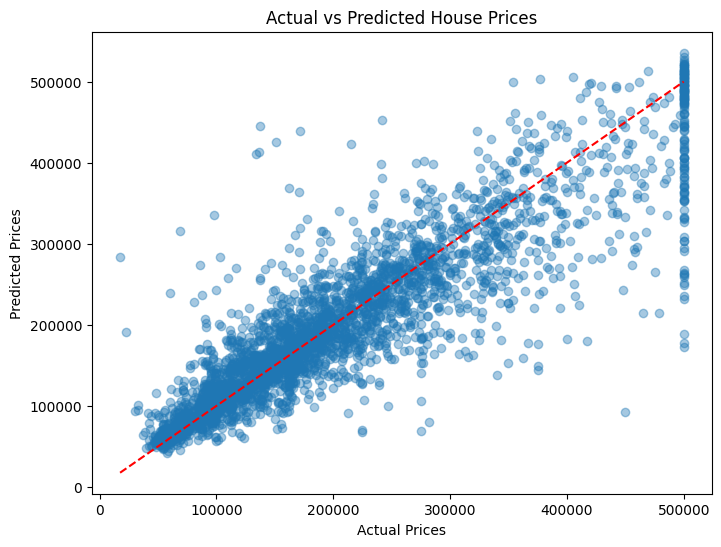

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Final Conclusion

The tuned RBF SVR became the strongest regression model in the project.

The experiment demonstrated:
- the power of nonlinear kernel methods
- the importance of preprocessing and scaling
- proper validation/test workflow
- the effectiveness of hyperparameter optimization

Most importantly, this project evolved from:
> simple equation fitting

to:
> similarity-based nonlinear machine learning.

The final model achieved strong predictive performance while maintaining good generalization on unseen test data.